In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [84]:
# Chargement du dataset
iris = load_iris()

print(type(iris))
print("Head:\n", iris.data[:5])
print("\n Cible:\n", iris.target[:5])
print("\n Attributs:\n", iris.feature_names)
print("\n Espèces:\n", iris.target_names)
print("\n Desc:\n", iris.DESCR)


<class 'sklearn.utils._bunch.Bunch'>
Head:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

 Cible:
 [0 0 0 0 0]

 Attributs:
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 Espèces:
 ['setosa' 'versicolor' 'virginica']

 Desc:
 .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.

In [85]:
nom_colonnes = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df_s = pd.DataFrame(data = iris.data, columns = nom_colonnes)

df_s['cible'] = iris.target

df_s['espèces'] = df_s['cible'].map(dict(enumerate(iris.target_names)))

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width  cible
0           5.1          3.5           1.4          0.2    0.0
1           4.9          3.0           1.4          0.2    0.0
2           4.7          3.2           1.3          0.2    0.0
3           4.6          3.1           1.5          0.2    0.0
4           5.0          3.6           1.4          0.2    0.0


In [86]:
# Nouvelle cible si O alors Setosa sinon (1 ou 2) Autres
df = df_s[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
df.loc[df_s['cible'] == 0, 'cible'] = 0
df.loc[df_s['cible'] > 0, 'cible'] = 1

df.loc[df['cible'] == 0, 'espèce'] = 'Setosa'
df.loc[df['cible'] > 0, 'espèce'] = 'Autre'

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width  cible  espèce
0           5.1          3.5           1.4          0.2    0.0  Setosa
1           4.9          3.0           1.4          0.2    0.0  Setosa
2           4.7          3.2           1.3          0.2    0.0  Setosa
3           4.6          3.1           1.5          0.2    0.0  Setosa
4           5.0          3.6           1.4          0.2    0.0  Setosa


C:\Users\sarrj\AppData\Local\Temp\ipykernel_19940\2753604331.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df_s['cible'] == 0, 'cible'] = 0


In [87]:
#### On effectue une analyse exploratoire des données
# on regarde les types 
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
cible           float64
espèce           object
dtype: object

In [88]:
# Vérifier l'existence de valeurs nulles (on remarque qu'il n'y a pas de tous dans les données)
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
cible           0
espèce          0
dtype: int64

In [89]:
# Vue statistiques sur les données (moy, min, max, quartiles, etc.)
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,cible
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,0.666667
std,0.828066,0.435866,1.765298,0.762238,0.472984
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,1.000000
max,7.900000,4.400000,6.900000,2.500000,1.000000


<Axes: >

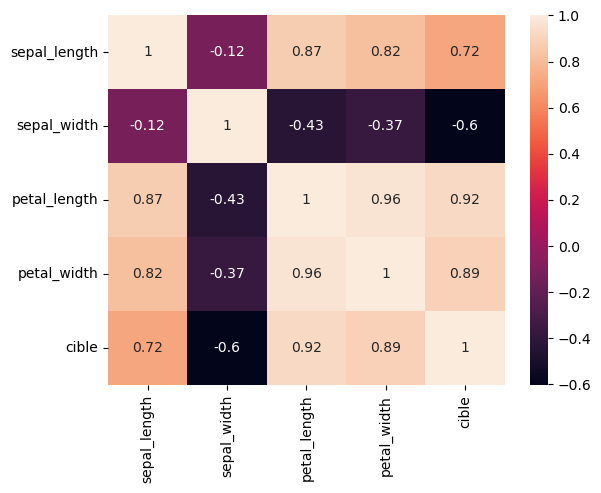

In [90]:
# Matrice de corrélation pour avoir un aperçu sur les liens entres les atts. pour le choix des features
df = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'cible']]
sns.heatmap(df.corr(), annot = True)

# Remarque une forte corrélation entre la cible et les colonnes sepal_length, petal_length et petal_width
# Les colonnes petal_length et petal_width sont beaucoup plus corrélé avec l'espèce. 
#En effet, quand leur valeurs augmentent on tends vers l'espèce 2 (Virginica ). La colonne sepal_length est moins corrélé. Ce constat démontre que les fleurs de l'espèce Setosa (0)  
# ont les plus large taille de sepal que celles de l'espèce Virginica

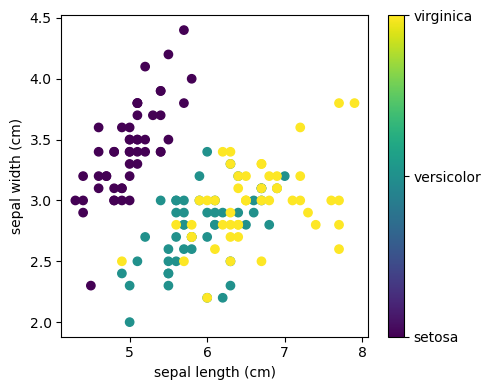

In [91]:
# On a ajoute un scatter plot pour mieux voir comment voir cette corrélation
# Le gaphique montre que les felurs des espèces Virginica et Versica sont proches en tailles. 
# Mais que celles de l'espèce Setosa forma un cluster à part

x_index = 0 # sepal_length
y_index = 1 # sepal_width

formatter = plt.FuncFormatter(lambda i, *args: iris.target_names[int(i)])
plt.figure(figsize=(5, 4))
plt.scatter(iris.data[:, x_index], iris.data[:, y_index], c=iris.target)
plt.colorbar(ticks=[0, 1, 2], format=formatter)
plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])
plt.tight_layout()
plt.show()

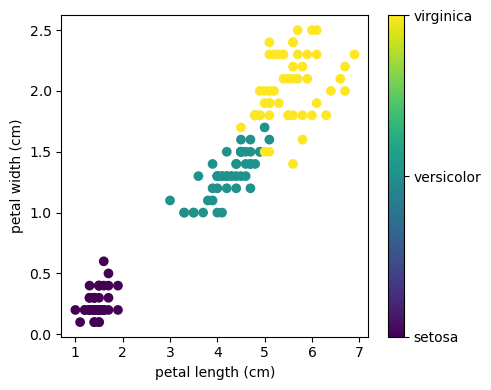

In [92]:
# Pour les dimension du petal on remarque que chaque espèce a apparemment des valeurs qui lui sont propre.
x_index = 2 #pepal_length
y_index = 3 #pepal_width

formatter = plt.FuncFormatter(lambda i, *args: iris.target_names[int(i)])
plt.figure(figsize=(5, 4))
plt.scatter(iris.data[:, x_index], iris.data[:, y_index], c=iris.target)
plt.colorbar(ticks=[0, 1, 2], format=formatter)
plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])
plt.tight_layout()
plt.show()


In [93]:
# Prediction de l'espèce suivant les dimension
# Séparer les données en features (X) et target (y)
X = df.copy()
y = X.pop('cible')

# Nous divisons le modèle en test et train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify = y)

# On standardize pour avoir une échelle consistant tout en gardant une relation proportionnelle
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [94]:
df.cible.value_counts(normalize= True)
# Le baseline de cette prédiction est de 1/2

cible
1.0    0.666667
0.0    0.333333
Name: proportion, dtype: float64

In [95]:
# Instance de l'estimateur
model = LinearRegression()

# Fournir les données au modèle
model.fit(X_train, y_train) 

# Précision (accuracy du modèle)
model.score(X_test, y_test)

0.8752688282137482

In [98]:
# Utilisation de la cross validation pour assurer la robustess du modèle
scores = cross_val_score(model, X_train, y_train, cv = 10)
print(np.mean(scores))

0.8974857024156707
